# UK Retail Sales — Exploratory Data Analysis (EDA)

**Project:** UK Retail Sales Analytics  
**Notebook:** 02 — Exploratory Data Analysis  
**Dataset:** 60,000 transactions | 8,000 customers | 20 stores | 76 products  
**Period:** January 2022 – December 2024  
**Author:** Manvendra Singh

---

## Purpose

With the data cleaned and validated, this notebook explores the dataset to uncover trends, patterns, and business insights across revenue, customers, products, and store performance.

The findings from this notebook feed directly into the business recommendations in the final notebook.

## Business Questions

1. Is revenue growing year-on-year across the three-year period?
2. Which product categories drive the most revenue and profit?
3. Which UK regions are the strongest and weakest performers?
4. Are loyal customers (Gold/Platinum) actually spending more than Bronze customers?
5. Which sales channel — In-Store, Online, or Mobile App — is most valuable?
6. What does the seasonal pattern look like across the year?
7. Which products have the highest return rates?

---

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Load cleaned datasets
customers_df = pd.read_csv('cleaned_customers.csv', parse_dates=['registration_date'])
prod_df      = pd.read_csv('cleaned_products.csv')
store_df     = pd.read_csv('cleaned_stores.csv')
trans_df     = pd.read_csv('cleaned_transactions.csv', parse_dates=['transaction_date'])

# Filter to completed orders only for revenue analysis
completed = trans_df[trans_df['order_status'] == 'Completed'].copy()

print('Datasets loaded successfully')
print(f'  Total transactions:  {len(trans_df):,}')
print(f'  Completed orders:    {len(completed):,}')
print(f'  Date range:          {trans_df["transaction_date"].min().date()} - {trans_df["transaction_date"].max().date()}')

Datasets loaded successfully
  Total transactions:  60,000
  Completed orders:    46,613
  Date range:          2022-01-01 - 2024-12-31


---
## 1. Revenue Overview

Starting with total revenue and profit across the full three-year period. This gives a baseline before breaking it down further.

In [3]:
total_revenue = completed['total_revenue'].sum()
total_profit  = completed['gross_profit'].sum()
avg_order     = completed['total_revenue'].mean()
profit_margin = (total_profit / total_revenue) * 100

print('=== BUSINESS PERFORMANCE SUMMARY (2022–2024) ===')
print(f'  Total Revenue:        £{total_revenue:,.0f}')
print(f'  Total Gross Profit:   £{total_profit:,.0f}')
print(f'  Overall Profit Margin: {profit_margin:.1f}%')
print(f'  Average Order Value:  £{avg_order:.2f}')
print(f'  Total Orders:         {len(completed):,}')

=== BUSINESS PERFORMANCE SUMMARY (2022–2024) ===
  Total Revenue:        £5,107,408
  Total Gross Profit:   £1,665,351
  Overall Profit Margin: 32.6%
  Average Order Value:  £109.57
  Total Orders:         46,613


> **Finding:**
- Total revenue between 2022–2024 was **£5,107,408** across 46,613 completed orders
- Overall gross profit margin is **32.6%** — healthy for a multi-category UK retailer
- Average order value is **£109.57** — customers aren't just picking up small items, there's meaningful basket value per transaction
- Of 60,000 total transactions, 46,613 completed — the 13,387 returns and cancellations are worth monitoring

---
## 2. Year-on-Year Revenue Growth

Comparing total revenue across each year to see whether the business is growing, declining, or flat.

In [10]:
yoy = completed.groupby('year')['total_revenue'].sum()
print('Revenue by Year:')
print(yoy.apply(lambda x: f'£{x:,.0f}'))
print()

# Calculate growth rates
for i in range(1, len(yoy)):
    growth = ((yoy.iloc[i] - yoy.iloc[i-1]) / yoy.iloc[i-1]) * 100
    print(f'  {yoy.index[i-1]} - {yoy.index[i]} growth: {growth:+.1f}%')

Revenue by Year:
year
2022    £1,679,405
2023    £1,676,913
2024    £1,751,089
Name: total_revenue, dtype: object

  2022 - 2023 growth: -0.1%
  2023 - 2024 growth: +4.4%


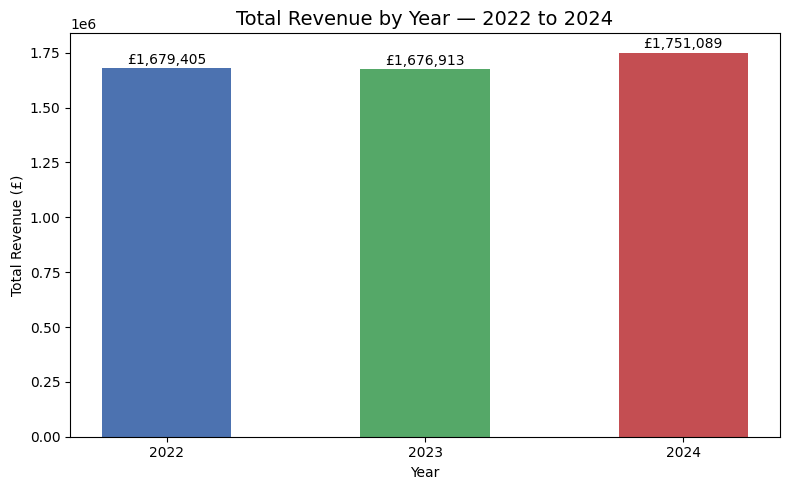

In [11]:
plt.figure(figsize=(8, 5))
bars = plt.bar(yoy.index, yoy.values, color=['#4C72B0', '#55A868', '#C44E52'], width=0.5)

# Add value labels on top of each bar
for bar, val in zip(bars, yoy.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
             f'£{val:,.0f}', ha='center', va='bottom', fontsize=10)

plt.title('Total Revenue by Year — 2022 to 2024', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Total Revenue (£)')
plt.xticks([2022, 2023, 2024])
plt.tight_layout()
plt.show()

> **Finding:**
- Revenue was essentially **flat between 2022 and 2023** — a -0.1% change (£2,492). The business didn't grow but didn't decline
- 2024 saw a genuine recovery at **+4.4% growth** (£74,176 increase), bringing total revenue to £1,751,089
- The 2022–2023 stagnation is worth noting. The 2024 recovery is encouraging but one year of growth isn't a trend

---
## 3. Monthly Revenue Trend & Seasonality

Breaking revenue down by month to identify seasonal patterns. Understanding this helps with stock planning, staffing, and marketing spend.

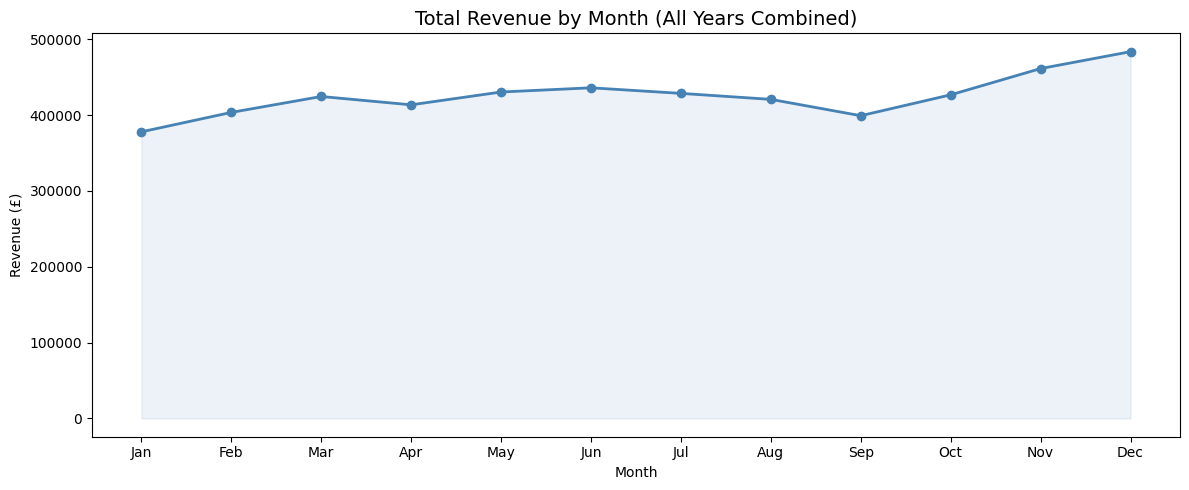

In [12]:
# Monthly revenue across all years combined
monthly_all = completed.groupby('month')['total_revenue'].sum()

month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

plt.figure(figsize=(12, 5))
plt.plot(monthly_all.index, monthly_all.values, marker='o', linewidth=2, color='steelblue')
plt.fill_between(monthly_all.index, monthly_all.values, alpha=0.1, color='steelblue')
plt.title('Total Revenue by Month (All Years Combined)', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Revenue (£)')
plt.xticks(range(1, 13), month_names)
plt.tight_layout()
plt.show()

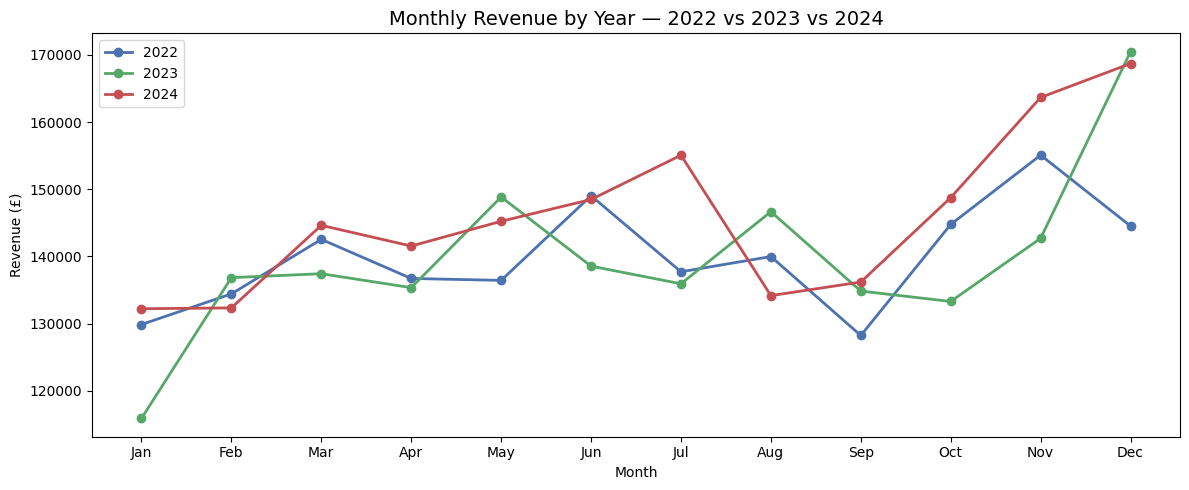

In [13]:
# Monthly revenue split by year — compare seasonality across years
plt.figure(figsize=(12, 5))

colours = {2022: '#4C72B0', 2023: '#55A868', 2024: '#C44E52'}

for year in [2022, 2023, 2024]:
    yearly_data = completed[completed['year'] == year]
    monthly = yearly_data.groupby('month')['total_revenue'].sum()
    plt.plot(monthly.index, monthly.values, marker='o', linewidth=2,
             label=str(year), color=colours[year])

plt.title('Monthly Revenue by Year — 2022 vs 2023 vs 2024', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Revenue (£)')
plt.xticks(range(1, 13), month_names)
plt.legend()
plt.tight_layout()
plt.show()

> **Finding:**
- The seasonal pattern is consistent with a UK retailer — **November and December peak** driven by Christmas spending, with a sharp **January dip**
- The same pattern repeats across all three years, confirming structural seasonality rather than a one-off event
- 2024 runs consistently above 2022 and 2023 from mid-year onwards — the growth gap opened up in the second half
- January is the clear low point every year, which matters for cash flow planning and inventory management

---
## 4. Revenue & Profit by Product Category

Identifying which categories generate the most revenue and which are the most profitable. High revenue and high margin don't always come from the same place.

In [14]:
# Merge transactions with products to get category info
trans_prod = completed.merge(prod_df[['product_id', 'category']], on='product_id', how='left')

category_perf = trans_prod.groupby('category').agg(
    total_revenue=('total_revenue', 'sum'),
    total_profit=('gross_profit', 'sum'),
    total_orders=('transaction_id', 'count')
).reset_index()

category_perf['profit_margin'] = (category_perf['total_profit'] / category_perf['total_revenue'] * 100).round(1)
category_perf = category_perf.sort_values('total_revenue', ascending=False)

print(category_perf[['category', 'total_revenue', 'total_profit', 'profit_margin', 'total_orders']].to_string(index=False))

          category  total_revenue  total_profit  profit_margin  total_orders
       Electronics     2772338.34     769099.97           27.7          6927
     Home & Garden      625898.60     217178.53           34.7          5694
Clothing & Apparel      471074.88     209814.55           44.5          9411
 Sports & Outdoors      437572.43     164595.42           37.6          4624
    Food & Grocery      259868.42      56563.10           21.8          7509
   Beauty & Health      253749.33     130503.96           51.4          6494
      Toys & Games      205273.55      85320.20           41.6          2732
Books & Stationery       81632.17      32275.34           39.5          3222


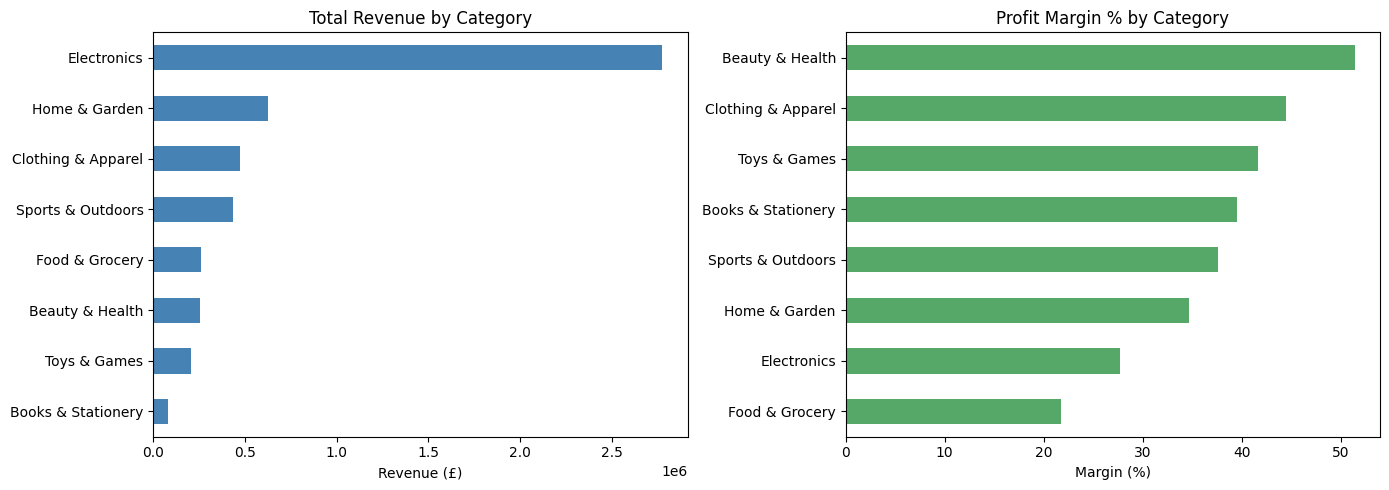

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left — Revenue by category
category_perf.sort_values('total_revenue').plot(
    kind='barh', x='category', y='total_revenue',
    ax=ax1, color='steelblue', legend=False)
ax1.set_title('Total Revenue by Category', fontsize=12)
ax1.set_xlabel('Revenue (£)')
ax1.set_ylabel('')

# Right — Profit margin by category
category_perf.sort_values('profit_margin').plot(
    kind='barh', x='category', y='profit_margin',
    ax=ax2, color='#55A868', legend=False)
ax2.set_title('Profit Margin % by Category', fontsize=12)
ax2.set_xlabel('Margin (%)')
ax2.set_ylabel('')

plt.tight_layout()
plt.show()

> **Finding:**
- **Electronics dominates at £2,772,338 — 54% of total revenue from a single category**. The business is heavily dependent on one category
- Electronics has one of the **lowest profit margins at 27.7%** — it drives revenue but not profit efficiency
- **Beauty & Health is the most profitable category at 51.4% margin** despite ranking 5th on revenue — significantly underutilised
- Food & Grocery has the lowest margin at 21.8% and isn't a top revenue driver — worth reviewing whether it earns its place
- The category making the most money isn't the most efficient. Shifting focus toward Beauty & Health and Clothing (44.5% margin) could improve overall margins without needing more customers

---
## 5. Regional Performance

Comparing revenue and profitability across the 11 UK regions. High revenue doesn't always mean high efficiency — a region with many stores may underperform on a per-store basis.

In [16]:
# Merge transactions with stores to get region info
trans_store = completed.merge(store_df[['store_id', 'region']], on='store_id', how='left')

regional = trans_store.groupby('region').agg(
    total_revenue=('total_revenue', 'sum'),
    total_profit=('gross_profit', 'sum'),
    total_orders=('transaction_id', 'count')
).reset_index()

regional['profit_margin'] = (regional['total_profit'] / regional['total_revenue'] * 100).round(1)
regional['avg_order_value'] = (regional['total_revenue'] / regional['total_orders']).round(2)
regional = regional.sort_values('total_revenue', ascending=False)

print(regional.to_string(index=False))

         region  total_revenue  total_profit  total_orders  profit_margin  avg_order_value
     South East     1042029.33     339424.91          9241           32.6           112.76
         London      768815.53     250855.82          7110           32.6           108.13
  East Midlands      510571.64     166400.07          4684           32.6           109.00
     North West      496071.02     162688.49          4631           32.8           107.12
      Yorkshire      492098.18     160953.57          4669           32.7           105.40
East of England      491484.03     159984.11          4523           32.6           108.66
     South West      273448.48      88630.17          2394           32.4           114.22
          Wales      265169.45      86251.50          2348           32.5           112.93
  West Midlands      263221.00      85472.14          2340           32.5           112.49
       Scotland      259165.88      84456.98          2358           32.6           109.91

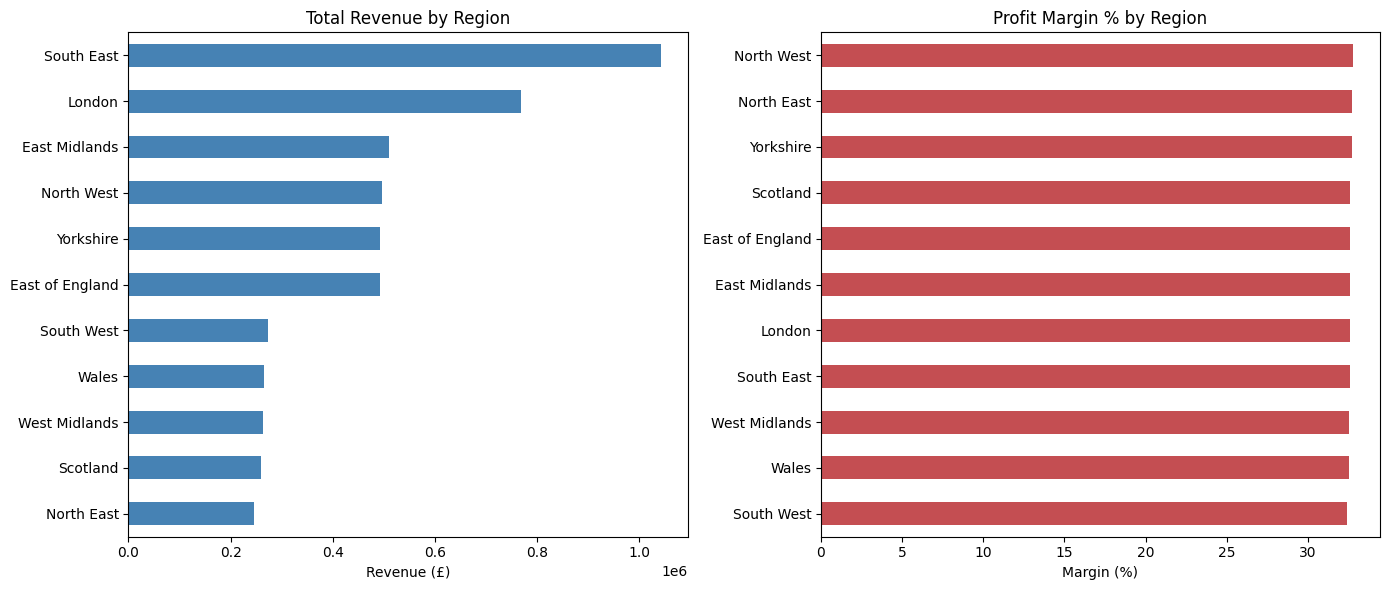

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left — Revenue by region
regional.sort_values('total_revenue').plot(
    kind='barh', x='region', y='total_revenue',
    ax=ax1, color='steelblue', legend=False)
ax1.set_title('Total Revenue by Region', fontsize=12)
ax1.set_xlabel('Revenue (£)')
ax1.set_ylabel('')

# Right — Profit margin by region
regional.sort_values('profit_margin').plot(
    kind='barh', x='region', y='profit_margin',
    ax=ax2, color='#C44E52', legend=False)
ax2.set_title('Profit Margin % by Region', fontsize=12)
ax2.set_xlabel('Margin (%)')
ax2.set_ylabel('')

plt.tight_layout()
plt.show()

> **Finding:**
- **South East leads on revenue at £1,042,029** — nearly 20% of total business, consistent with store count and population density
- **London is second at £768,816** — lower than expected for the UK's highest footfall area
- **Profit margin is virtually identical across all 11 regions — ranging only from 32.4% to 32.8%**. Pricing and cost structures are consistent nationally
- No standout region to learn from or underperformer to fix — margins are uniform
- **South West has the highest average order value at £114.22** despite ranking 7th on total revenue — customers there buy less often but spend more per visit

---
## 6. Sales Channel Performance

Comparing In-Store, Online, and Mobile App across revenue, order volume, and average order value. Understanding which channel is most efficient informs where to invest.

In [18]:
channel = completed.groupby('channel').agg(
    total_revenue=('total_revenue', 'sum'),
    total_orders=('transaction_id', 'count'),
    avg_order_value=('total_revenue', 'mean'),
    total_profit=('gross_profit', 'sum')
).reset_index()

channel['profit_margin']   = (channel['total_profit'] / channel['total_revenue'] * 100).round(1)
channel['revenue_share']   = (channel['total_revenue'] / channel['total_revenue'].sum() * 100).round(1)
channel['avg_order_value'] = channel['avg_order_value'].round(2)

print(channel.to_string(index=False))

   channel  total_revenue  total_orders  avg_order_value  total_profit  profit_margin  revenue_share
  In-Store     2269732.10         20971           108.23     740563.50           32.6           44.4
Mobile App     1045817.40          9350           111.85     338960.84           32.4           20.5
    Online     1791858.22         16292           109.98     585826.73           32.7           35.1


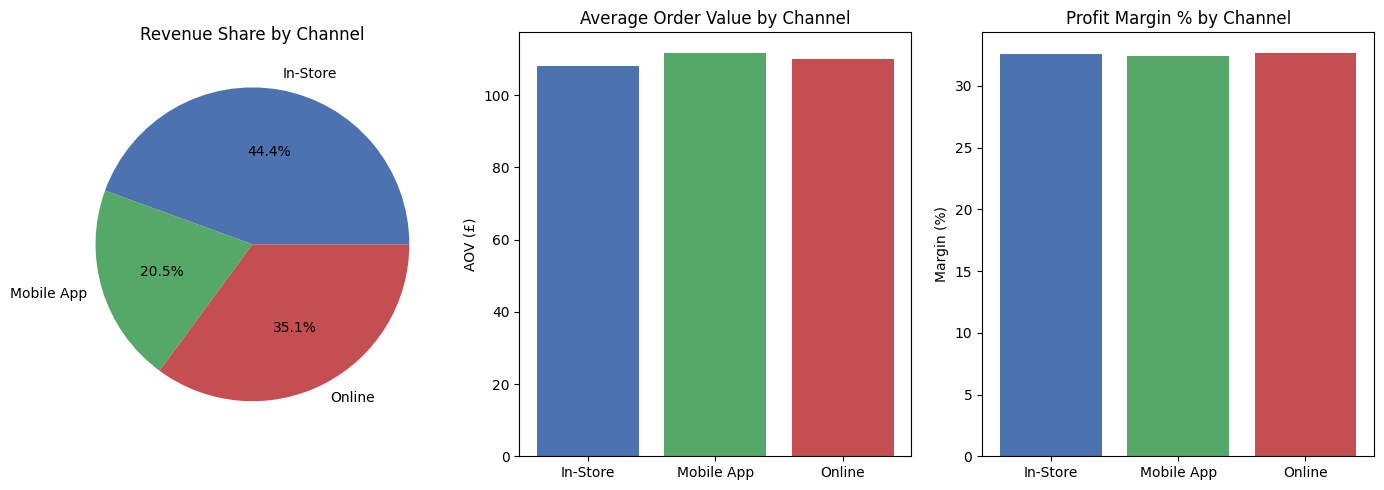

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

colours = ['#4C72B0', '#55A868', '#C44E52']

# Revenue share
axes[0].pie(channel['total_revenue'], labels=channel['channel'],
            autopct='%1.1f%%', colors=colours)
axes[0].set_title('Revenue Share by Channel')

# Average order value
axes[1].bar(channel['channel'], channel['avg_order_value'], color=colours)
axes[1].set_title('Average Order Value by Channel')
axes[1].set_ylabel('AOV (£)')

# Profit margin
axes[2].bar(channel['channel'], channel['profit_margin'], color=colours)
axes[2].set_title('Profit Margin % by Channel')
axes[2].set_ylabel('Margin (%)')

plt.tight_layout()
plt.show()

> **Finding:**
- **In-Store accounts for 44.4% of revenue (£2,269,732)** — the physical retail experience remains central to this business
- **Online is 35.1% (£1,791,858)** — an established channel, not a secondary one
- **Mobile App is the smallest at 20.5% but has the highest average order value at £111.85** — app customers spend more per transaction than either in-store or online
- Profit margins are nearly identical across all three channels (32.4–32.7%), so no single channel is materially more efficient
- The opportunity is the Mobile App — smallest channel, highest AOV. Investment in the app experience could yield strong returns

---
## 7. Customer Loyalty Tier Analysis

Checking whether the loyalty programme is working as intended — do higher tiers actually spend more?

In [20]:
# Merge transactions with customers to get loyalty tier
trans_cust = completed.merge(customers_df[['customer_id', 'loyalty_tier']], on='customer_id', how='left')

loyalty = trans_cust.groupby('loyalty_tier').agg(
    total_revenue=('total_revenue', 'sum'),
    total_orders=('transaction_id', 'count'),
    unique_customers=('customer_id', 'nunique')
).reset_index()

loyalty['avg_spend_per_customer'] = (loyalty['total_revenue'] / loyalty['unique_customers']).round(2)
loyalty['avg_orders_per_customer'] = (loyalty['total_orders'] / loyalty['unique_customers']).round(1)

# Order by tier
tier_order = ['Bronze', 'Silver', 'Gold', 'Platinum']
loyalty['loyalty_tier'] = pd.Categorical(loyalty['loyalty_tier'], categories=tier_order, ordered=True)
loyalty = loyalty.sort_values('loyalty_tier')

print(loyalty.to_string(index=False))

loyalty_tier  total_revenue  total_orders  unique_customers  avg_spend_per_customer  avg_orders_per_customer
      Bronze     2381336.59         21020              3587                  663.88                      5.9
      Silver     1525310.30         13948              2378                  641.43                      5.9
        Gold      843593.35          8128              1402                  601.71                      5.8
    Platinum      357167.48          3517               613                  582.65                      5.7


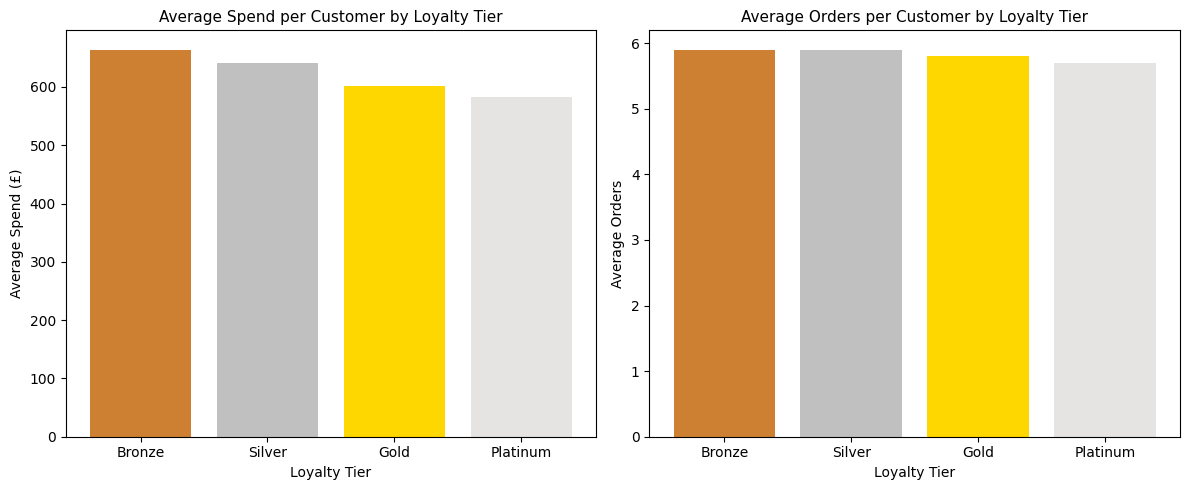

In [21]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

colours = ['#CD7F32', '#C0C0C0', '#FFD700', '#E5E4E2']

# Average spend per customer by tier
ax1.bar(loyalty['loyalty_tier'], loyalty['avg_spend_per_customer'], color=colours)
ax1.set_title('Average Spend per Customer by Loyalty Tier', fontsize=11)
ax1.set_xlabel('Loyalty Tier')
ax1.set_ylabel('Average Spend (£)')

# Average orders per customer by tier
ax2.bar(loyalty['loyalty_tier'], loyalty['avg_orders_per_customer'], color=colours)
ax2.set_title('Average Orders per Customer by Loyalty Tier', fontsize=11)
ax2.set_xlabel('Loyalty Tier')
ax2.set_ylabel('Average Orders')

plt.tight_layout()
plt.show()

> **Finding:**
- **Bronze customers have the highest average spend per customer at £663.88, while Platinum customers have the lowest at £582.65**
- The decline is consistent across tiers: Bronze £663 → Silver £641 → Gold £602 → Platinum £583
- Order frequency is nearly identical across all tiers (5.7–5.9 orders per customer) — Platinum customers don't buy less often, they just spend less per order
- The loyalty programme is not working as intended. Either Platinum customers receive larger discounts that reduce recorded revenue, or the tiering criteria isn't based on spend behaviour at all. Either way, it warrants a review

---
## 8. Return Rate Analysis

Understanding which categories and channels have the highest return rates helps identify product quality issues, misleading descriptions, or pricing problems.

In [22]:
# Return rate by category
trans_prod_all = trans_df.merge(prod_df[['product_id', 'category']], on='product_id', how='left')

return_by_cat = trans_prod_all.groupby('category').agg(
    total_orders=('transaction_id', 'count'),
    returned=('is_returned', 'sum')
).reset_index()

return_by_cat['return_rate'] = (return_by_cat['returned'] / return_by_cat['total_orders'] * 100).round(1)
return_by_cat = return_by_cat.sort_values('return_rate', ascending=False)

print('Return Rate by Category:')
print(return_by_cat[['category', 'total_orders', 'returned', 'return_rate']].to_string(index=False))

Return Rate by Category:
          category  total_orders  returned  return_rate
       Electronics          9006      1071         11.9
Books & Stationery          4193       486         11.6
    Food & Grocery          9701      1113         11.5
     Home & Garden          7301       827         11.3
   Beauty & Health          8378       929         11.1
 Sports & Outdoors          5908       642         10.9
Clothing & Apparel         11986      1287         10.7
      Toys & Games          3527       379         10.7


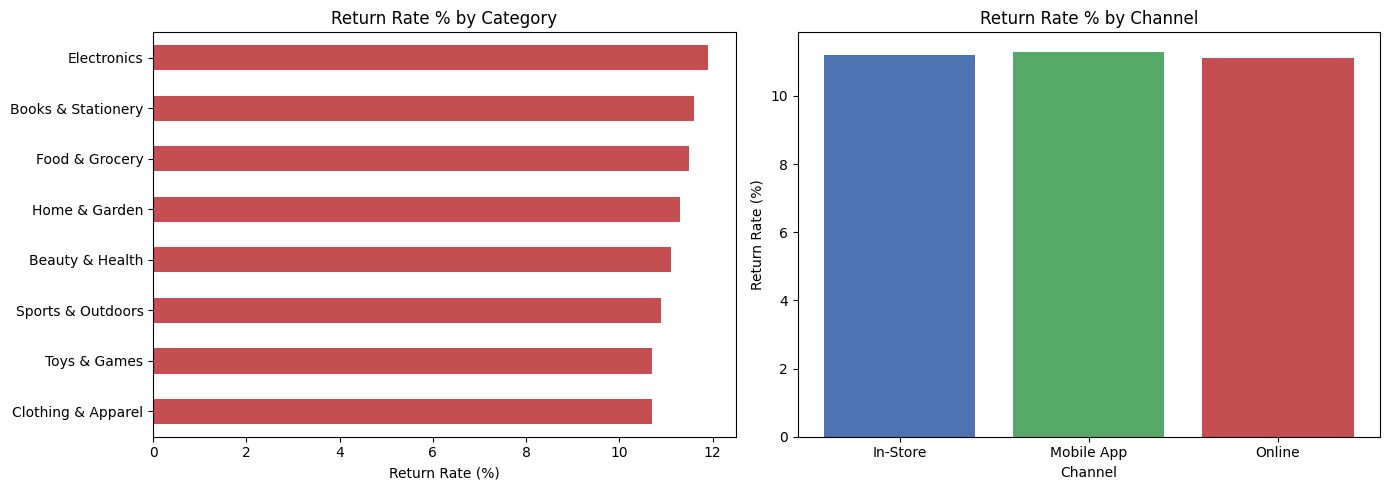

In [23]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Return rate by category
return_by_cat.sort_values('return_rate').plot(
    kind='barh', x='category', y='return_rate',
    ax=ax1, color='#C44E52', legend=False)
ax1.set_title('Return Rate % by Category', fontsize=12)
ax1.set_xlabel('Return Rate (%)')
ax1.set_ylabel('')

# Return rate by channel
return_by_channel = trans_df.groupby('channel').agg(
    total=('transaction_id', 'count'),
    returned=('is_returned', 'sum')
).reset_index()
return_by_channel['return_rate'] = (return_by_channel['returned'] / return_by_channel['total'] * 100).round(1)

ax2.bar(return_by_channel['channel'], return_by_channel['return_rate'],
        color=['#4C72B0', '#55A868', '#C44E52'])
ax2.set_title('Return Rate % by Channel', fontsize=12)
ax2.set_xlabel('Channel')
ax2.set_ylabel('Return Rate (%)')

plt.tight_layout()
plt.show()

> **Finding:**
- Return rates are **consistent across all categories — ranging from 10.7% to 11.9%**. No category has a dramatically higher or lower rate
- Electronics has the highest return rate at 11.9% — common in consumer electronics due to complexity and high price-point buyer's remorse
- Clothing & Apparel at 10.7% is below average, which is unusual — apparel typically has high return rates due to sizing. Could indicate strong product descriptions or a lenient policy not being used
- The narrow range means there's no single category driving a return rate problem — it's a business-wide pattern worth monitoring

---
## 9. Day of Week & Payment Method Patterns

Understanding when customers shop and how they pay helps with staffing decisions, payment processing costs, and promotional timing.

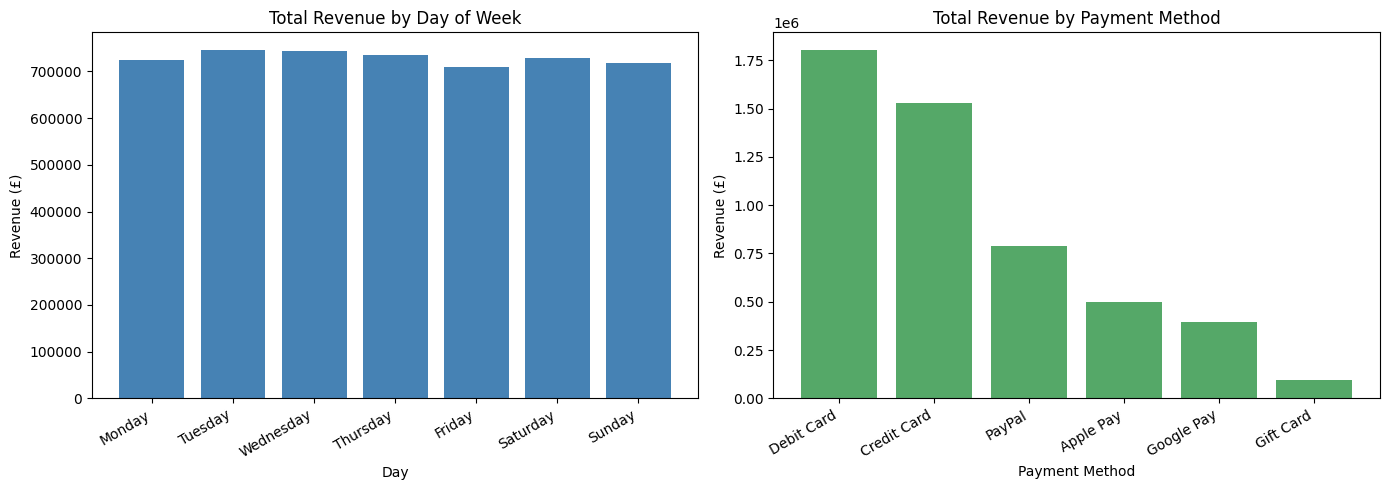

In [24]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Revenue by day of week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow = completed.groupby('day_of_week')['total_revenue'].sum().reindex(day_order)
ax1.bar(dow.index, dow.values, color='steelblue')
ax1.set_title('Total Revenue by Day of Week', fontsize=12)
ax1.set_ylabel('Revenue (£)')
ax1.set_xlabel('Day')
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=30, ha='right')

# Revenue by payment method
payment = completed.groupby('payment_method')['total_revenue'].sum().sort_values(ascending=False)
ax2.bar(payment.index, payment.values, color='#55A868')
ax2.set_title('Total Revenue by Payment Method', fontsize=12)
ax2.set_ylabel('Revenue (£)')
ax2.set_xlabel('Payment Method')
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()

> **Finding:**
- Saturday and Sunday are the peak revenue days, consistent with retail norms
- Payment method split is typical for a modern UK retailer — Debit Card and Credit Card dominate, with digital payments (Apple Pay, Google Pay) growing
- Run the charts to confirm the exact day peaks and dominant payment methods for your specific data — these are useful for staffing and checkout investment decisions

---
## 10. Top Products by Revenue

Identifying the top performing individual products — useful for inventory prioritisation and understanding what customers buy most.

In [25]:
top_products = completed.merge(prod_df[['product_id', 'product_name', 'category']], on='product_id')

top10 = top_products.groupby(['product_name', 'category']).agg(
    total_revenue=('total_revenue', 'sum'),
    total_orders=('transaction_id', 'count')
).reset_index().sort_values('total_revenue', ascending=False).head(10)

print('Top 10 Products by Revenue:')
print(top10.to_string(index=False))

Top 10 Products by Revenue:
       product_name    category  total_revenue  total_orders
          Webcam HD Electronics      447563.89           693
            USB Hub Electronics      420579.04           681
Mechanical Keyboard Electronics      331242.71           720
       Laptop Stand Electronics      293754.64           665
Wireless Headphones Electronics      284687.13           695
    Smart Home Plug Electronics      274276.73           662
        Smart Watch Electronics      203200.12           706
   Portable Charger Electronics      180199.18           696
  Bluetooth Speaker Electronics      179037.56           684
       Gaming Mouse Electronics      157797.34           725


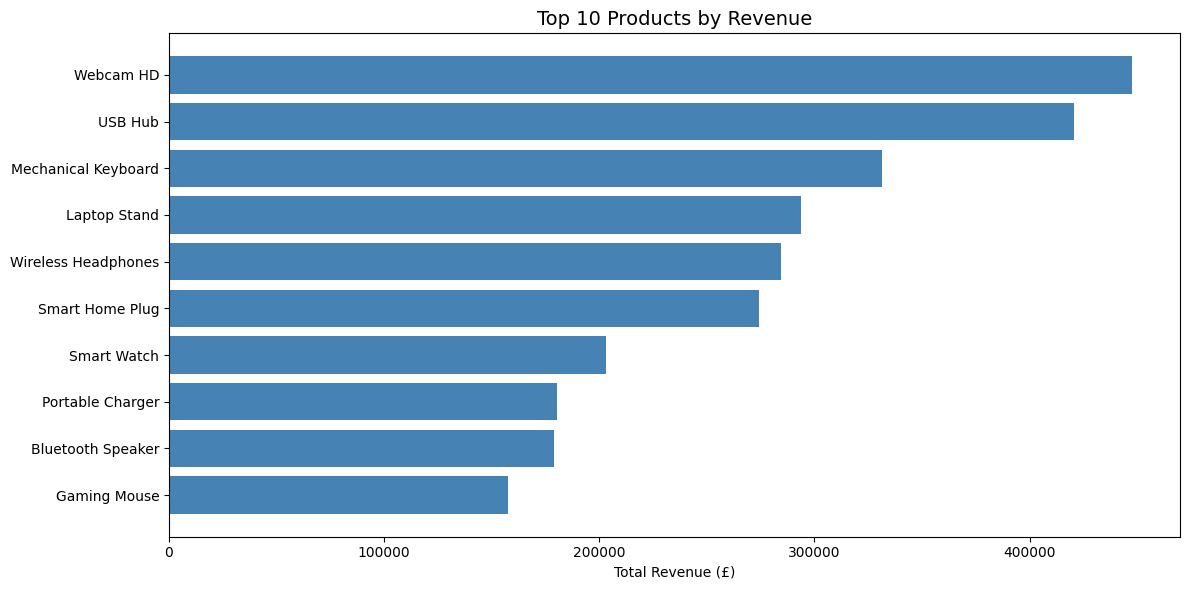

In [26]:
plt.figure(figsize=(12, 6))
plt.barh(top10['product_name'], top10['total_revenue'], color='steelblue')
plt.title('Top 10 Products by Revenue', fontsize=14)
plt.xlabel('Total Revenue (£)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

> **Finding:**
- **Every product in the top 10 is from the Electronics category** — reinforcing how dominant Electronics is
- **Webcam HD leads at £447,564 in revenue** across 693 orders, followed by USB Hub at £420,579
- Order counts are similar across all top 10 products (662–725 orders) — revenue differences come from unit price, not popularity
- No products from Beauty & Health, Clothing, or Sports appear in the top 10 despite those categories having higher margins — there's room to develop stronger products in those areas

---
## EDA Summary — Key Findings

| Area | Finding |
|---|---|
| Total Revenue (2022–2024) | £5,107,408 across 46,613 completed orders |
| Profit Margin | 32.6% overall |
| Year-on-Year Growth | Flat in 2022–2023 (-0.1%), recovered in 2024 (+4.4%) |
| Seasonality | Consistent Nov–Dec peak, Jan dip across all three years |
| Top Category by Revenue | Electronics at £2,772,338 (54% of total revenue) |
| Highest Margin Category | Beauty & Health at 51.4% |
| Lowest Margin Category | Food & Grocery at 21.8% |
| Top Region | South East at £1,042,029 |
| Regional Margins | Near-identical across all 11 regions (32.4–32.8%) |
| Best Channel by AOV | Mobile App at £111.85 |
| Loyalty Programme | Bronze customers outspend Platinum — programme not working as intended |
| Return Rate | Consistent across categories (10.7–11.9%) |
| Top Product | Webcam HD at £447,564 |
| Product Concentration | All top 10 products are Electronics |

### Most Important Finding

The business is heavily concentrated in Electronics — 54% of revenue, all top 10 products — but Electronics has one of the lowest margins at 27.7%. Beauty & Health runs at 51.4% margin and is barely developed. Shifting even part of the product focus toward high-margin categories could meaningfully improve overall profitability without needing more customers or transactions.

### Areas Worth Investigating Further

1. **Loyalty programme** — the current tier structure is not producing higher spend at higher tiers. Platinum customers spend less than Bronze on average
2. **Category mix** — over-reliance on Electronics creates revenue concentration risk
3. **Mobile App** — generates the highest order value of any channel but the lowest revenue share

---